## EDA for Netflix Movies and TV Shows

In [48]:
# Importing libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# uploading file

df = pd.read_csv('netflix_titles.csv')

## Data Inspection

In [122]:
# Dataset dimensions: rows and columns

df.shape

(8807, 12)

In [15]:
# Column names, data types, and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Preview the first 5 records

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
# Preview the last 5 records

df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [123]:
# Checking missing values

df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
# Checking for duplicates

df.duplicated().sum()

np.int64(0)

## Inspection by Feature

#### type

In [26]:
# Distinct values in the 'type' column

df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

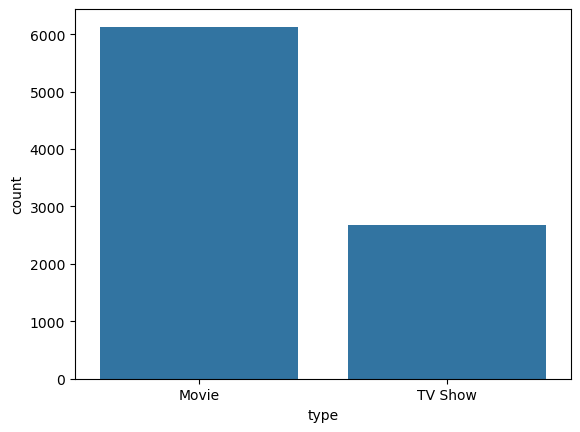

In [64]:
# Distribution of content types (Movies vs TV Shows)

sns.countplot(x='type', data=df)
plt.show()

#### title

In [23]:
# Distinct values in the 'title' column

df['title'].nunique()

8807

#### dicrector

In [25]:
# Distinct values in the 'director' column

df['director'].nunique()

4528

In [94]:
# Percentage of missing values

df['director'].isna().mean()*100

np.float64(29.908027705234474)

#### cast

In [27]:
# Distinct values in the 'cast' column

df['cast'].nunique()

7692

In [95]:
# Percentage of missing values

df['cast'].isna().mean()*100

np.float64(9.367548540933349)

#### country

In [28]:
# Distinct values in the 'country' column

df['country'].nunique()

748

In [96]:
# Percentage of missing values 

df['country'].isna().mean()*100

np.float64(9.435676166685592)

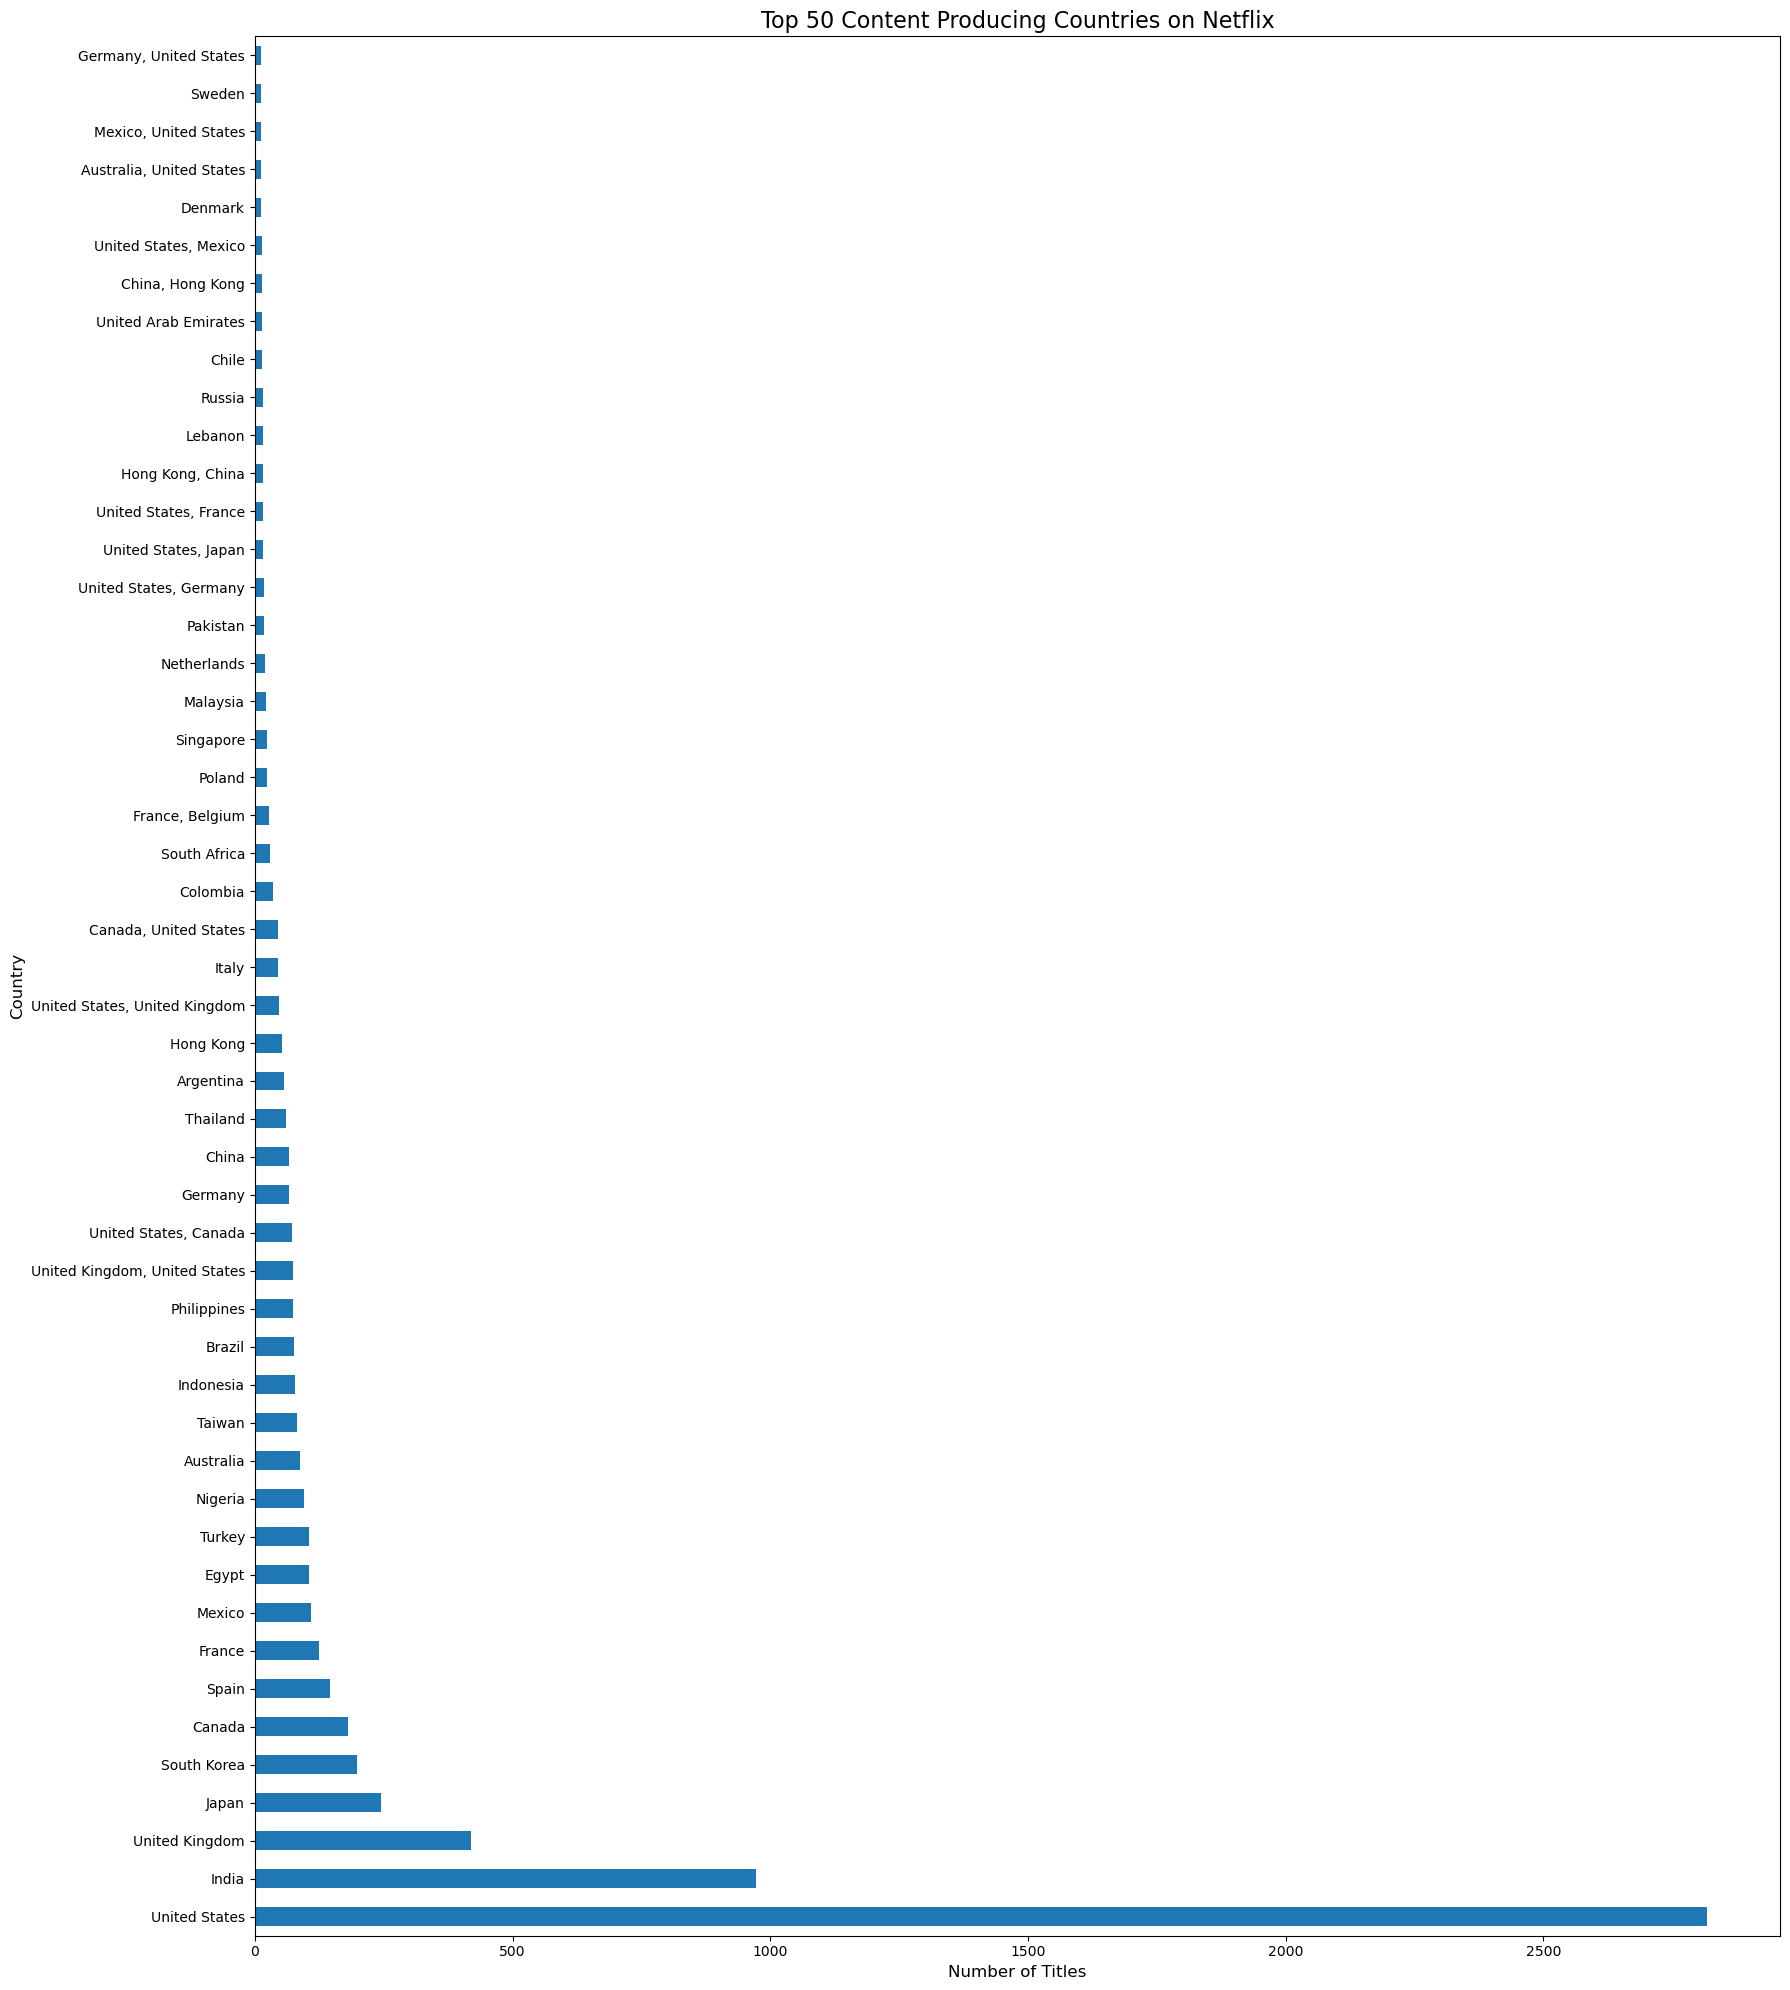

In [124]:
# Top 50 countries by number of titles produced

df['country'].value_counts().head(50).plot(kind='barh', figsize=(18, 20))
plt.title('Top 50 Content Producing Countries on Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

#### date_added

In [31]:
# Distinct values in the 'date_added' column

df['date_added'].nunique()

1767

In [107]:
# Convert 'date_added' to datetime, stripping whitespace and handling mixed date formats

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')

In [119]:
# Earliest date a title was added to Netflix

df['date_added'].min()

Timestamp('2008-01-01 00:00:00')

In [120]:
# Most recent date a title was added to Netflix

df['date_added'].max()

Timestamp('2021-09-25 00:00:00')

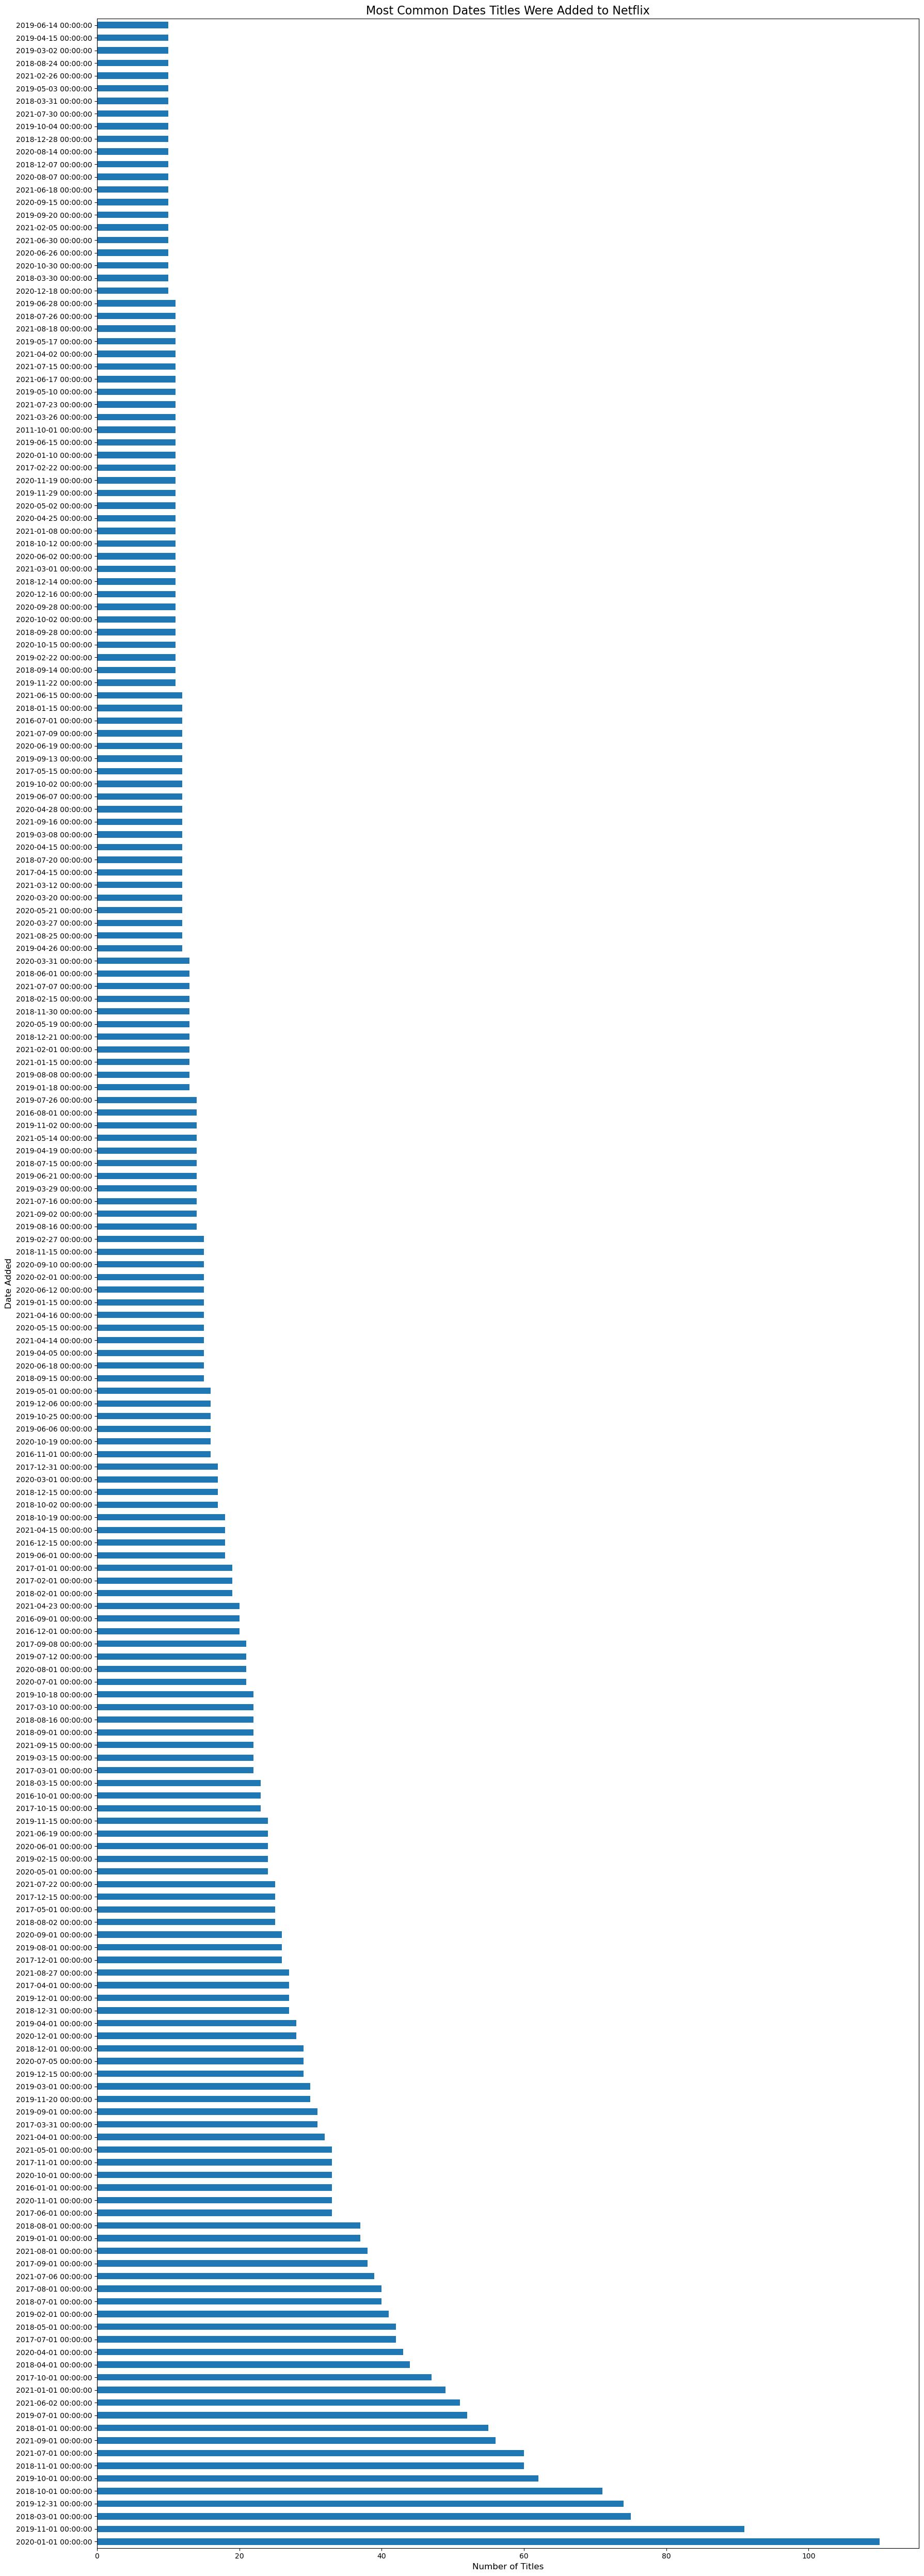

In [125]:
# Top 200 most common dates titles were added to Netflix

df['date_added'].value_counts().head(200).plot(kind='barh', figsize=(18, 50))
plt.title('Most Common Dates Titles Were Added to Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Date Added', fontsize=12)
plt.tight_layout()
plt.show()

#### rating

In [38]:
# Distinct values in the 'rating' column

df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

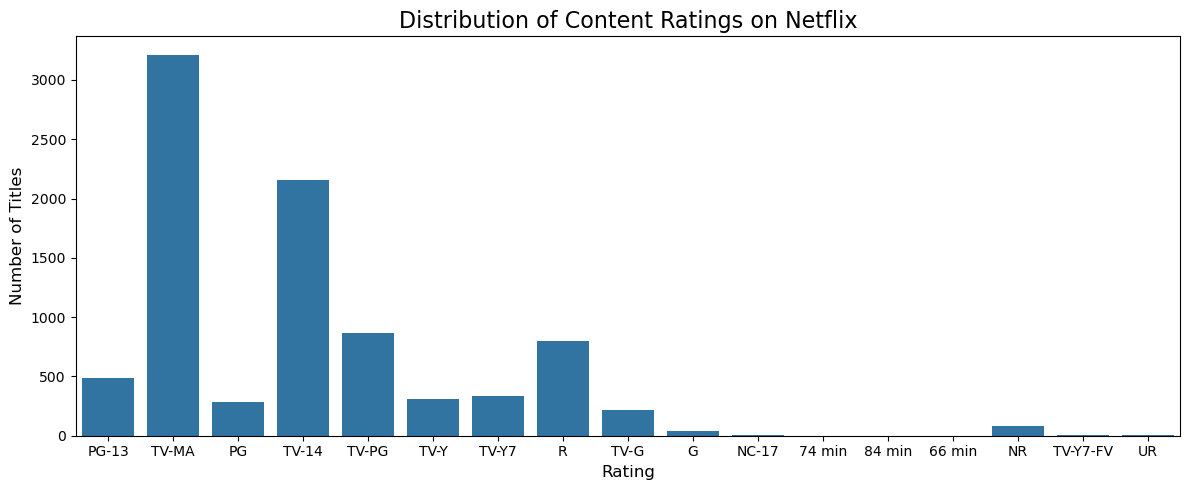

In [126]:
# Distribution of content ratings across Netflix titles

plt.figure(figsize=(12, 5))
sns.countplot(x='rating', data=df)
plt.title('Distribution of Content Ratings on Netflix', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.tight_layout()
plt.show()

#### duration

In [41]:
# Distinct values in the 'duration' column

df['duration'].nunique()

220

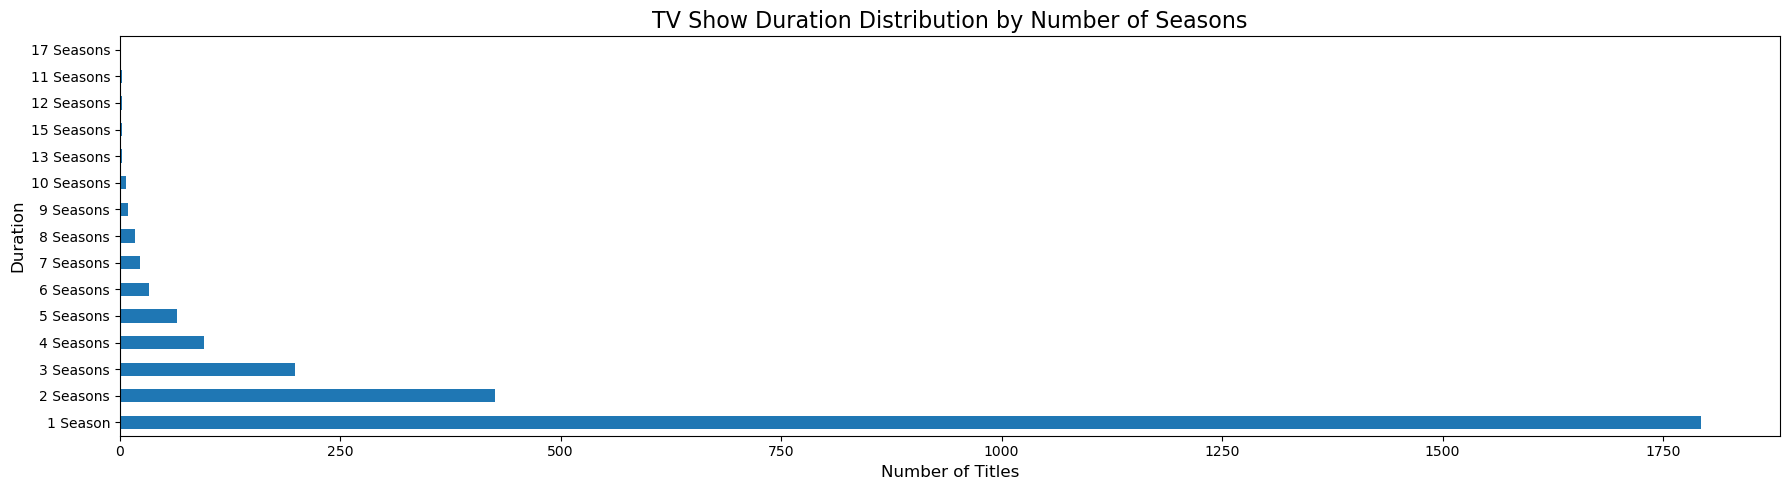

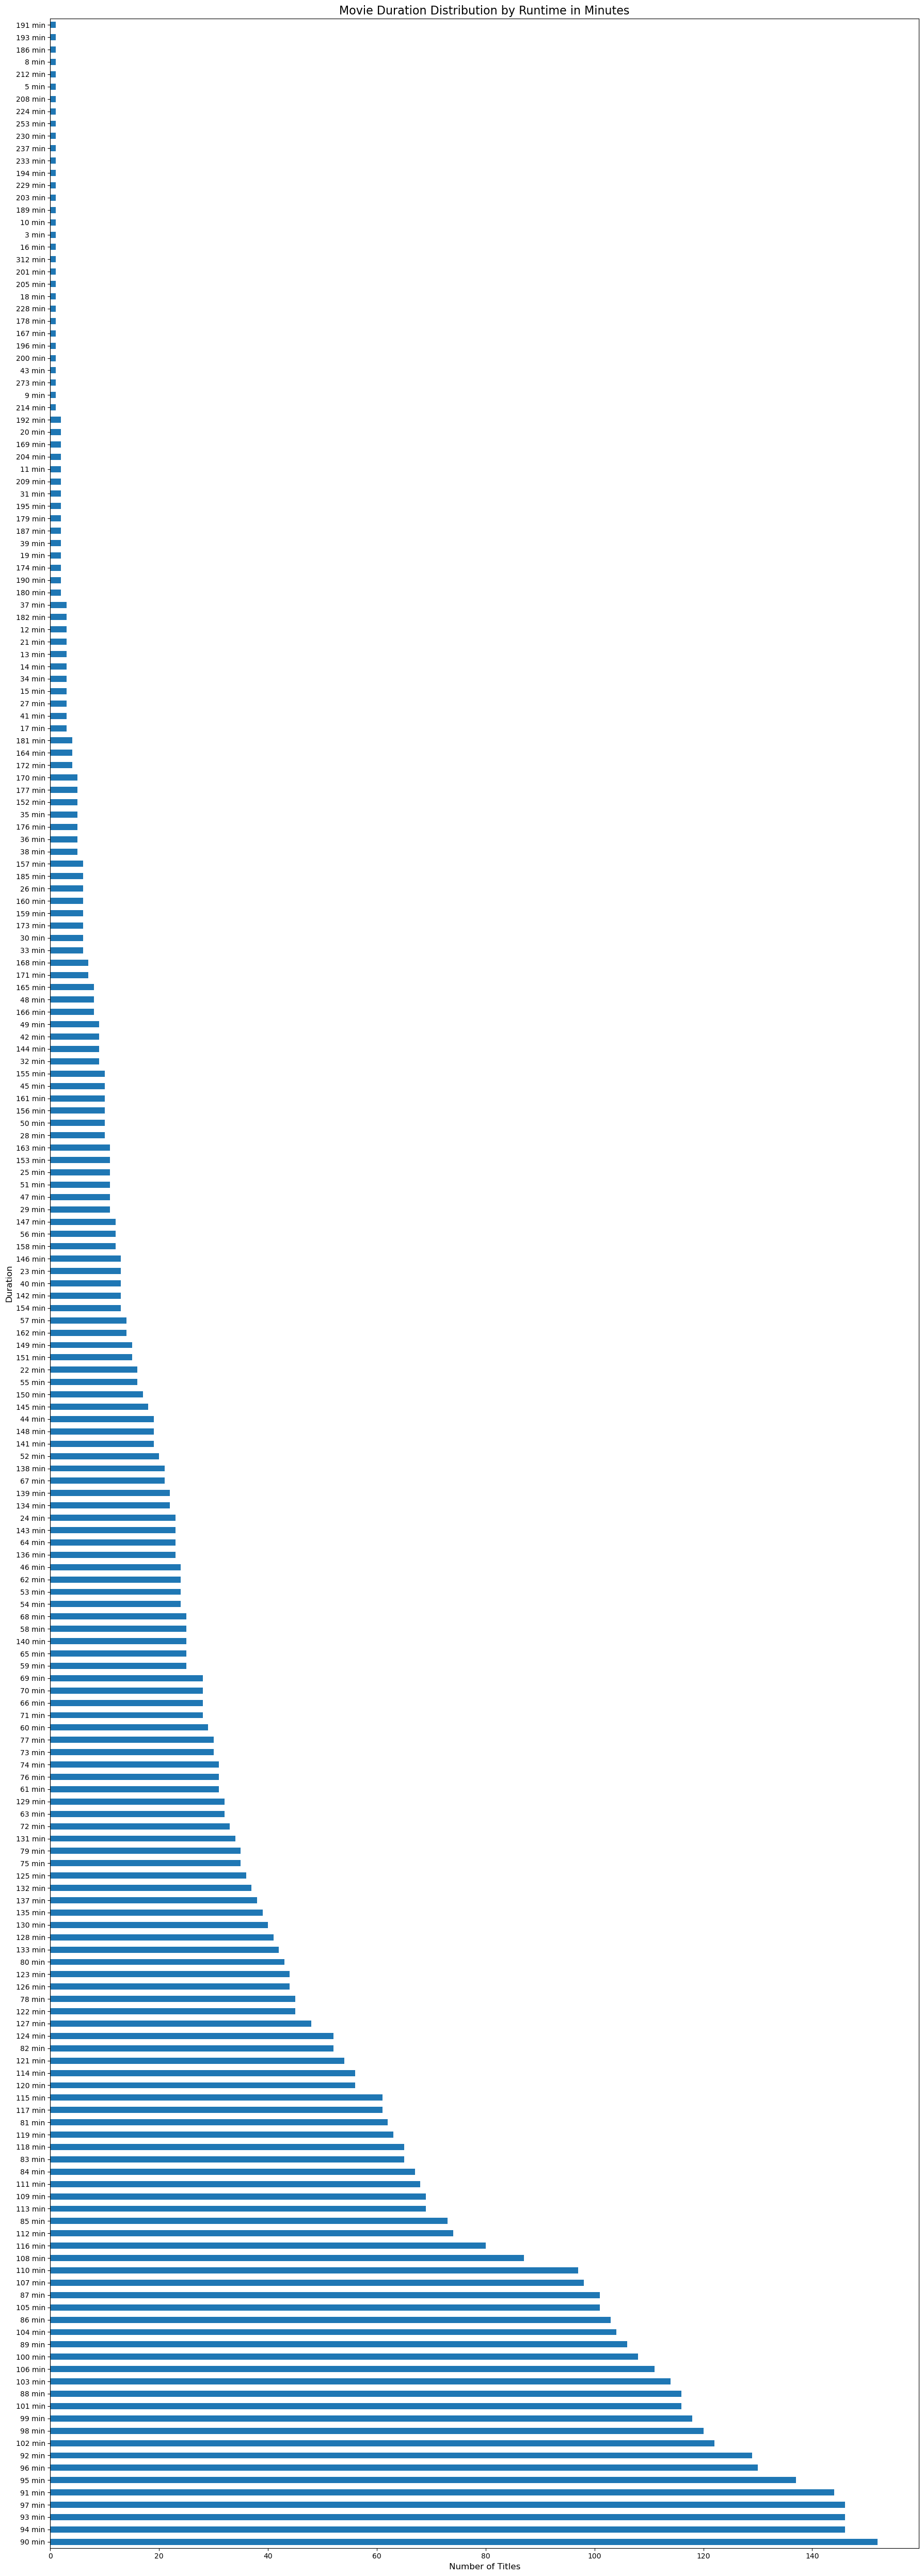

In [128]:
# Filter TV Shows and plot distribution by number of seasons

shows = df[df['type'] == 'TV Show']
shows['duration'].value_counts().plot(kind='barh', figsize=(18, 5))
plt.title('TV Show Duration Distribution by Number of Seasons', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Duration', fontsize=12)
plt.tight_layout()
plt.show()

# Filter Movies and plot distribution by runtime in minutes

movies = df[df['type'] == 'Movie']
movies['duration'].value_counts().plot(kind='barh', figsize=(18, 50))
plt.title('Movie Duration Distribution by Runtime in Minutes', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Duration', fontsize=12)
plt.tight_layout()
plt.show()

#### listed_in

In [42]:
# Distinct values in the 'listed_in' column

df['listed_in'].nunique()

514

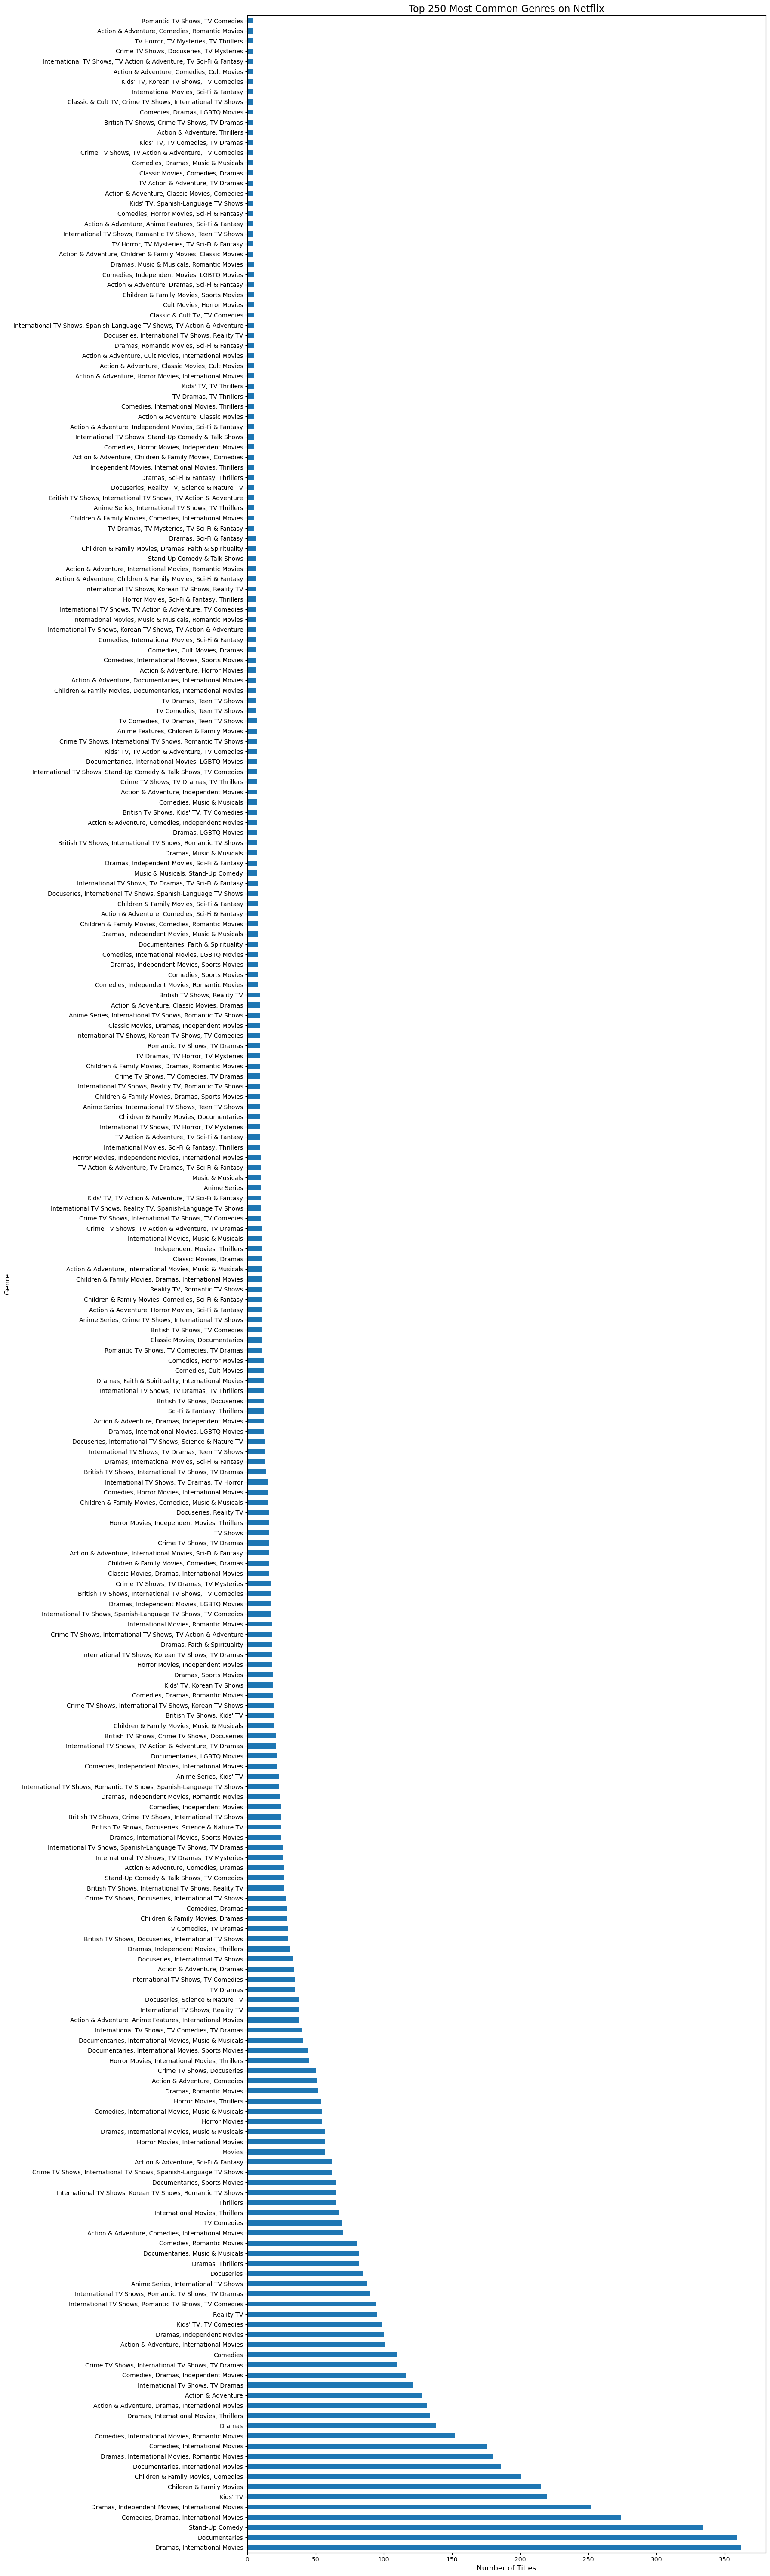

In [129]:
# Top 250 most common genres/categories on Netflix

df['listed_in'].value_counts().head(250).plot(kind='barh', figsize=(18, 60))
plt.title('Top 250 Most Common Genres on Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

#### description

In [43]:
# Distinct values in the 'description' column

df['description'].nunique()

8775

#### release_year

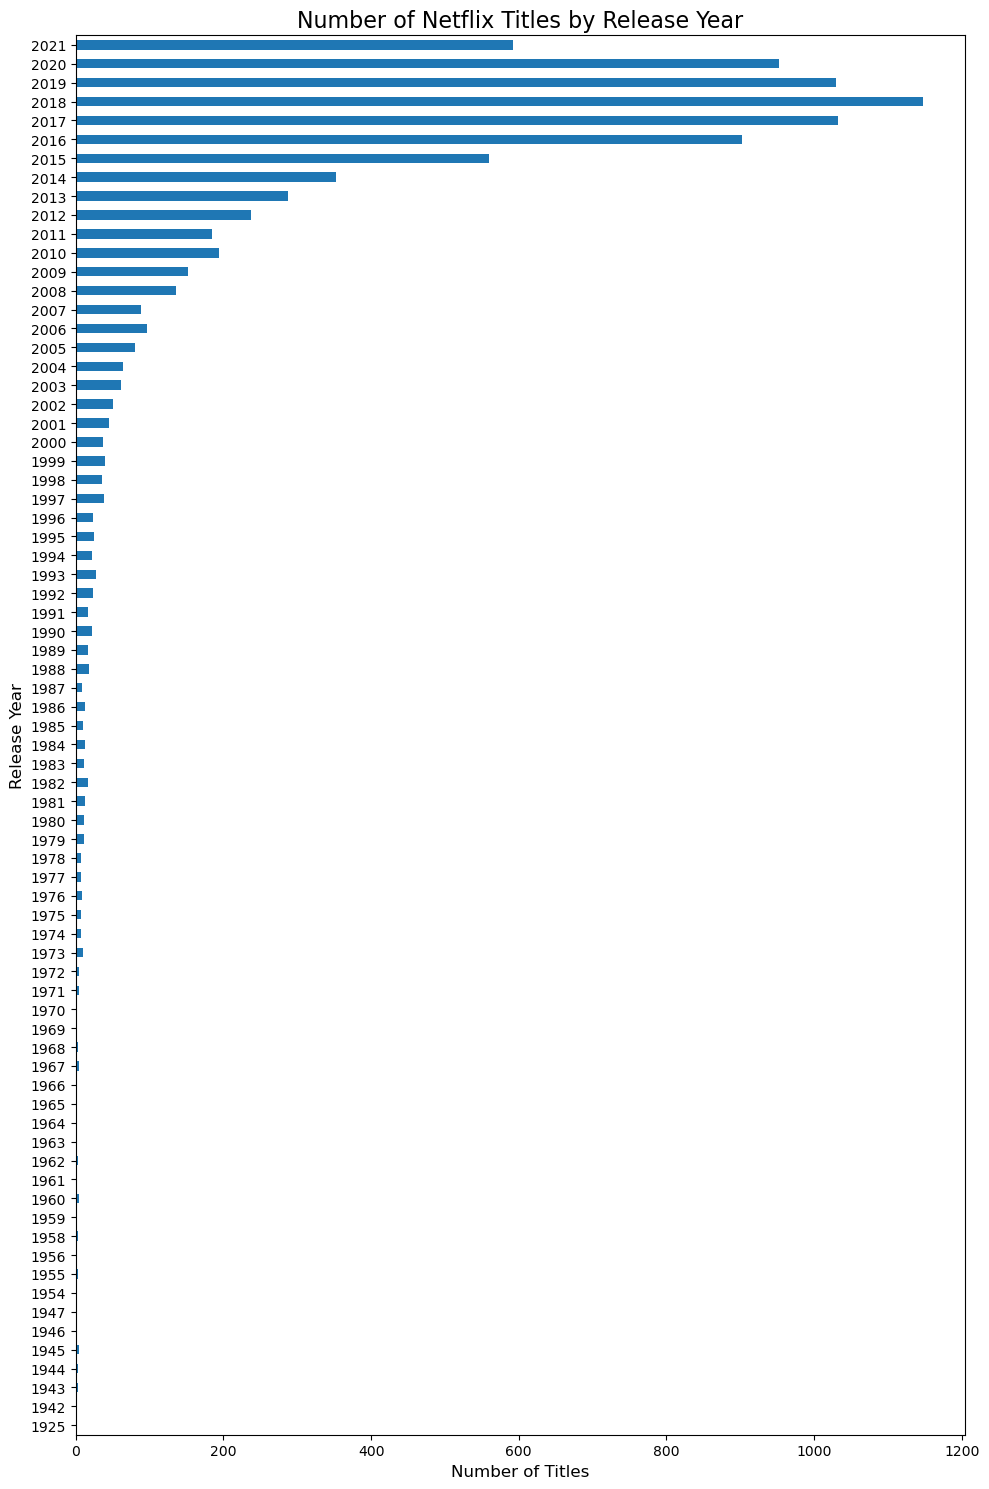

In [149]:
# Frequency distribution of titles by release year

df['release_year'].value_counts().sort_index().plot(kind='barh', figsize=(10, 15))
plt.title('Number of Netflix Titles by Release Year', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Release Year', fontsize=12)
plt.tight_layout()
plt.show()

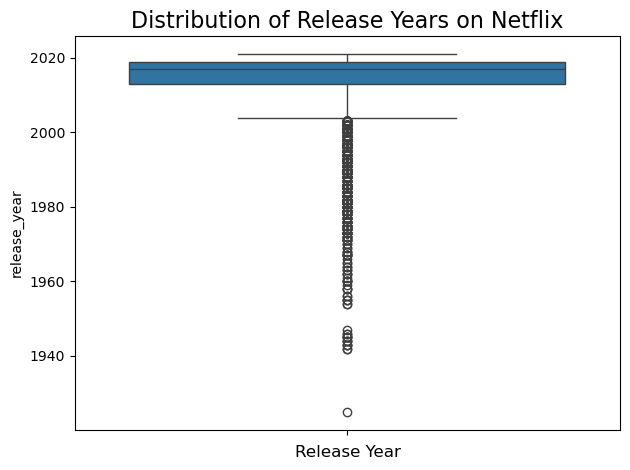

In [130]:
# Distribution and outliers of title release years

sns.boxplot(df['release_year'])
plt.title('Distribution of Release Years on Netflix', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.tight_layout()
plt.show()

In [132]:
# Calculate interquartile range to identify outliers in release year

Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1


# Flag titles outside 1.5x IQR as outliers and report their proportion

outliers = df[(df['release_year'] < Q1 - 1.5*IQR) | (df['release_year'] > Q3 + 1.5*IQR)]
print(f'Outliers in release_year: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

Outliers in release_year: 719 (8.16%)
